<a href="https://colab.research.google.com/github/SeranomTheGreat/3D-SpatialJEPA/blob/main/3djepa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Training 3D-JEPA on normal world physics rules...
Epoch 025 | Total Loss: 0.0656 | Target MSE: 0.0184
Epoch 050 | Total Loss: 0.0507 | Target MSE: 0.0198
Epoch 075 | Total Loss: 0.0375 | Target MSE: 0.0217
Epoch 100 | Total Loss: 0.0249 | Target MSE: 0.0196
Epoch 125 | Total Loss: 0.0185 | Target MSE: 0.0173
Epoch 150 | Total Loss: 0.0151 | Target MSE: 0.0139

Running Evaluation featuring injected Teleportation Anomaly...


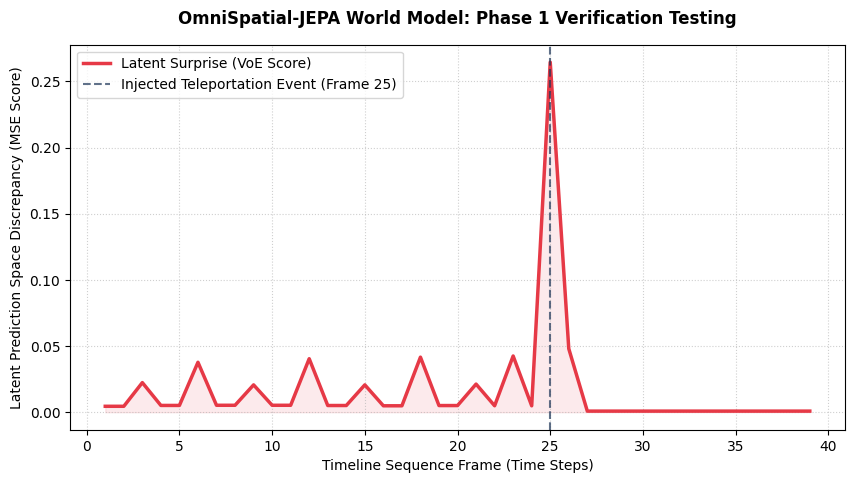

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Force GPU usage if available on Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. ARCHITECTURE DEFINITION
# ==========================================

class VoxelJEPAEncoder(nn.Module):
    """Compresses 3D voxels [C, Z, Y, X] into a spatial latent grid."""
    def __init__(self, in_channels=1, latent_channels=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_channels, 4, kernel_size=3, stride=2, padding=1),  # Downsample spatial dims
            nn.BatchNorm3d(4),
            nn.ReLU(),
            nn.Conv3d(4, latent_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(latent_channels),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class SpatialPredictor(nn.Module):
    """Predicts next 3D latent state given current state + control/ego-motion."""
    def __init__(self, latent_channels=8, cond_dim=1):
        super().__init__()
        self.cond_mapping = nn.Sequential(
            nn.Linear(cond_dim, latent_channels),
            nn.ReLU()
        )
        self.conv_block = nn.Sequential(
            nn.Conv3d(latent_channels * 2, latent_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(latent_channels),
            nn.ReLU(),
            nn.Conv3d(latent_channels, latent_channels, kernel_size=3, padding=1)
        )
    def forward(self, z, cond):
        B, C, Z, Y, X = z.shape
        cond_feat = self.cond_mapping(cond).view(B, C, 1, 1, 1).expand(B, C, Z, Y, X)
        combined = torch.cat([z, cond_feat], dim=1)
        return z + self.conv_block(combined)

def compute_sigreg_loss(z, target_variance=1.0, eps=1e-4):
    """Prevents latent representation collapse across the 3D grid spatial domain."""
    B, C, Z, Y, X = z.shape
    features = z.permute(0, 2, 3, 4, 1).reshape(-1, C)
    N = features.shape[0]
    if N <= 1: return torch.tensor(0.0, device=z.device)

    std = torch.sqrt(torch.var(features, dim=0) + eps)
    std_loss = torch.mean(F.relu(target_variance - std))

    centered = features - torch.mean(features, dim=0)
    cov_matrix = (centered.T @ centered) / (N - 1)
    diag_mask = torch.eye(C, device=z.device)
    cov_loss = torch.sum((cov_matrix * (1 - diag_mask)) ** 2) / C
    return std_loss + cov_loss

# ==========================================
# 2. SYNTHETIC 3D WORLD GENERATION (PHASE 1)
# ==========================================

def generate_moving_object_sequence(seq_len=40, grid_dim=(8, 16, 16), dynamic_anomaly=False):
    """Generates a sequence of 3D voxel grids where an object moves predictably."""
    Z, Y, X = grid_dim
    voxels_seq = torch.zeros(seq_len, 1, Z, Y, X)
    controls_seq = torch.zeros(seq_len - 1, 1) # Representing constant forward velocity step

    obj_x = 2.0
    velocity = 0.35 # Fixed delta per step

    for t in range(seq_len):
        # Trigger an intentional physical violation mid-sequence
        if dynamic_anomaly and t == 25:
            obj_x += 4.5  # Instantaneous impossible teleport jump
        elif t > 0:
            obj_x += velocity

        # Draw a basic 3D cubic bounds box in the voxel matrix
        x_idx = int(clamp(obj_x, 0, X-1))
        voxels_seq[t, 0, 3:5, 7:9, x_idx:min(x_idx+2, X)] = 1.0
        if t < seq_len - 1:
            controls_seq[t, 0] = velocity

    return voxels_seq.to(device), controls_seq.to(device)

def clamp(n, minn, maxn): return max(min(n, maxn), minn)

# ==========================================
# 3. TRAINING OPERATIONS LOOP
# ==========================================

# Instantiate Pipeline Elements
encoder = VoxelJEPAEncoder().to(device)
predictor = SpatialPredictor().to(device)
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(predictor.parameters()), lr=0.01)

print("Training 3D-JEPA on normal world physics rules...")
encoder.train(); predictor.train()

for epoch in range(150): # Rapid fitting over synthetic sample space
    voxels, controls = generate_moving_object_sequence(seq_len=30, dynamic_anomaly=False)
    optimizer.zero_grad()

    # Map visual sequences directly to latent matrices
    z = torch.stack([encoder(voxels[t].unsqueeze(0)) for t in range(30)], dim=1).squeeze(0)

    # Compute predictive modeling steps
    z_curr = z[:-1]
    z_next_pred = predictor(z_curr, controls)
    z_next_target = z[1:]

    # Optimization Penalties
    mse_loss = F.mse_loss(z_next_pred, z_next_target)
    reg_loss = compute_sigreg_loss(z)
    loss = mse_loss + 0.1 * reg_loss

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:03d} | Total Loss: {loss.item():.4f} | Target MSE: {mse_loss.item():.4f}")

# ==========================================
# 4. VIOLATION-OF-EXPECTATION EVALUATION TEST
# ==========================================

print("\nRunning Evaluation featuring injected Teleportation Anomaly...")
encoder.eval(); predictor.eval()

eval_seq_len = 40
with torch.no_grad():
    # Generate test set containing the impossible physics jump at step 25
    test_voxels, test_controls = generate_moving_object_sequence(seq_len=eval_seq_len, dynamic_anomaly=True)
    z_test = torch.stack([encoder(test_voxels[t].unsqueeze(0)) for t in range(eval_seq_len)], dim=1).squeeze(0)

    surprise_timeline = []

    for t in range(eval_seq_len - 1):
        z_curr = z_test[t].unsqueeze(0)
        action = test_controls[t].unsqueeze(0)

        # Predict where the 3D volume states SHOULD be
        z_next_pred = predictor(z_curr, action)
        z_next_actual = z_test[t+1].unsqueeze(0)

        # Calculate localized Surprise metric
        step_surprise = F.mse_loss(z_next_pred, z_next_actual).item()
        surprise_timeline.append(step_surprise)

# ==========================================
# 5. DATA PLOTTING VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(range(1, eval_seq_len), surprise_timeline, color='#e63946', linewidth=2.5, label='Latent Surprise (VoE Score)')
plt.axvline(x=25, color='#1d3557', linestyle='--', alpha=0.7, label='Injected Teleportation Event (Frame 25)')
plt.fill_between(range(1, eval_seq_len), surprise_timeline, color='#e63946', alpha=0.1)

plt.title("OmniSpatial-JEPA World Model: Phase 1 Verification Testing", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Timeline Sequence Frame (Time Steps)", fontsize=10)
plt.ylabel("Latent Prediction Space Discrepancy (MSE Score)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, loc='upper left')
plt.show()